# PART4_Small_number_HBs
Not all HBs are important to predict phenotypes.

So, check accuracy against the number of HBs selected by importance of each models

In [1]:
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set()

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_data_for_prediction import make_data, make_data_for_Tuning
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet, tuning_RandomForest
from modules.train_for_accuracy import train_GBLUP, GBLUP_coef, train_lightgbm, train_randomforest, train_Lasso, train_Enet

family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
trait_names = ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]
models = ["Lasso", "Enet", "LGBM", "RF"]
HB_num_set = [3000, 2000, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 75, 50, 25, 10]
CV=5
optuna_seed=1024

# Calculate accuracy of the model based on selected haplotype blocks

## Extract 3000~10 Haplotype blocks based on importances
importance means feature importances (RF, LGBM), coefs (Lasso, Enet), p-values (GBLUP) calculated by model

In [23]:
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")

for trait_name in ["LW_mean", "GN_mean", "LL_mean", "DTH_mean", "PN_mean", "Area.size.AS..mm2."]:
    with open('../data/PART3_Model_comparison/Compare_models_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for model in ['GBLUP', 'LGBM', 'RF', 'Lasso', 'Enet']:
        for HB_num in HB_num_set:
            for i in range(CV):
                path = "../data/PART4_Small_number_HBs/selected_genotype/{}_{}_{}_{}.csv.gz".format(trait_name, model, HB_num, i)
                imp = np.mean(summary.loc[(summary.iloc[:, 0] == trait_name) & (summary.iloc[:, 1] == i) & (summary.iloc[:, 2] == model), 6].values[0], axis=0)
                selected_indices = np.argsort(np.abs(imp))[::-1][:HB_num]
                genotype.loc[np.sort(selected_indices), :].to_csv(path, index=None, compression="gzip")

## Parameter tuning

In [ ]:
def tuning_multi(inputs): # inputs: CV, X, y, model
    model = inputs[3]
    if model == "Lasso":
        params = tuning_Lasso(inputs[1], inputs[2])
    elif model == "Enet":
        params = tuning_ElasticNet(inputs[1], inputs[2])
    elif model == "RF":
        params = tuning_RandomForest(inputs[1], inputs[2])
    elif model == "LGBM":
        params = tuning_LightGBM(inputs[1], inputs[2])
    return [inputs[0], params]

# function to make training dataset using selected HBs
def make_data_for_Tuning_selected_HBs(model, HB_num, family, family_list, trait_name, phenotype, CV, i):
    genotype = "../data/PART4_Small_number_HBs/selected_genotype/{}_{}_{}_{}.csv.gz".format(trait_name, model, HB_num, i)
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)
    return train_data[i][0], train_data[i][1]

# parameter tuning
for model in models:
    for trait_name in [trait_names[0]]:
        params = []
        print(model, trait_name)
        for HB_num in HB_num_set:
            print(model, trait_name, HB_num)
            # Tuning
            inputs_list = []
            for i in range(CV):
                X_train_i, y_train_i = make_data_for_Tuning_selected_HBs(model, HB_num, family, family_list, trait_name, phenotype, CV, i)
                inputs_list.append([i, X_train_i, y_train_i, model])
            p = Pool(CV)
            results = p.map(tuning_multi, inputs_list)
            p.close()
            params.extend([[trait_name, HB_num, result[0], result[1]] for result in results])

        pd.DataFrame(params).to_csv("../data/PART4_Small_number_HBs/{}_selected_HBs_byDCV_{}_params.csv".format(model, trait_name))

## Train models using selected HBs

In [ ]:
summary = []
for trait_name in trait_names:
    for HB_num in HB_num_set:
        for model in models:
            print(trait_name, model, HB_num)
            genotype = "../data/PART4_Small_number_HBs/selected_genotype/{}_{}_{}.csv".format(trait_name, model, HB_num)    
            test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False, log=False)
            
            for i in range(CV):
                print("CV{}".format(i))
                # get parameters
                if model != 'GBLUP':
                    params = pd.read_csv("../data/PART4_Small_number_HBs/{}_selected_HBs_{}_params.csv".format(model, trait_name), index_col=0)
                    params.columns = ["trait", "HB_num", "CV", "params"]
                    params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i) & (params["HB_num"] == HB_num), "params"].values[0])
                tmp_test_data = test_data[i]
                tmp_train_data = train_data[i]
                
                # train model
                if model == 'GBLUP':
                    test_pred, h2, r2, acc_RIL = train_GBLUP(tmp_test_data, tmp_train_data, genotype)
                    imps = []
                elif model == 'LGBM':
                    test_preds, r2, acc_RIL, imps = train_lightgbm(tmp_test_data, tmp_train_data, CV, params)
                    test_pred = np.mean(test_preds, axis=0)
                elif model == 'Lasso':
                    test_pred, r2, acc_RIL, imps = train_Lasso(tmp_test_data, tmp_train_data, params)
                elif model == 'Enet':
                    test_pred, r2, acc_RIL, imps = train_Enet(tmp_test_data, tmp_train_data, params)
                elif model == 'RF':
                    test_pred, r2, acc_RIL, imps = train_randomforest(tmp_test_data, tmp_train_data, CV, params)

                summary.append([trait_name, HB_num, model, i, test_pred, r2, acc_RIL, imps])

with open('../data/PART4_Small_number_HBs/Compare_models_by_all_RILs_selected_HBs_byDCV.pic.bin', 'wb') as p:
    pickle.dump(summary, p)

# Check accuracy of genomic prediction model agains the number of haplotype blocks

In [2]:
model_order = {'GBLUP': 0, 'Lasso': 1, 'Enet': 2, 'LGBM': 3, 'RF': 4}
palette = sns.color_palette(['#56B4E9', '#009E73', '#E69F00', '#0072B2', '#F0E442'])

LW_mean


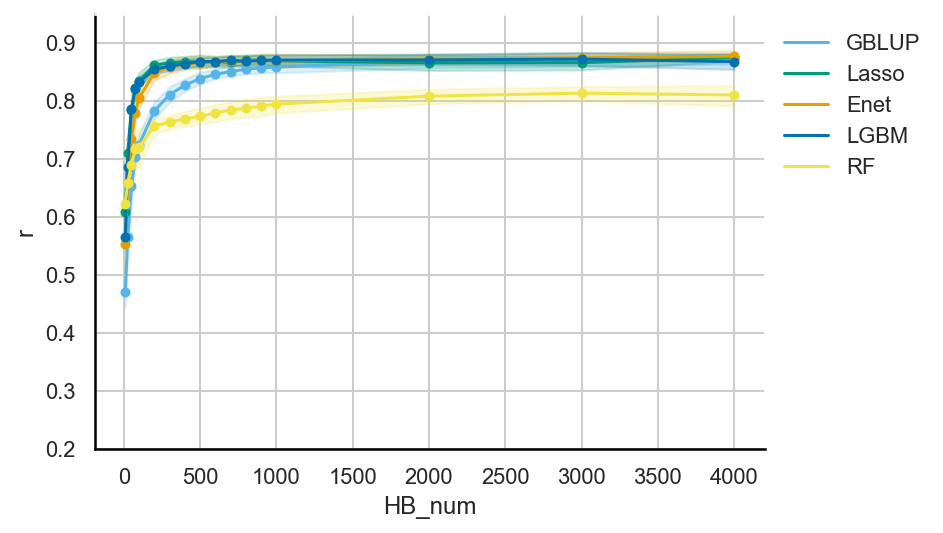

GN_mean


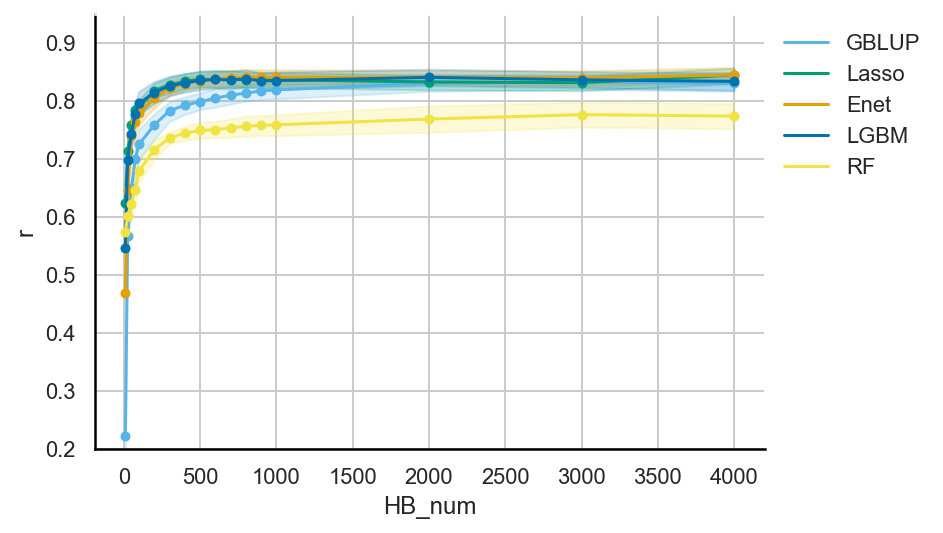

LL_mean


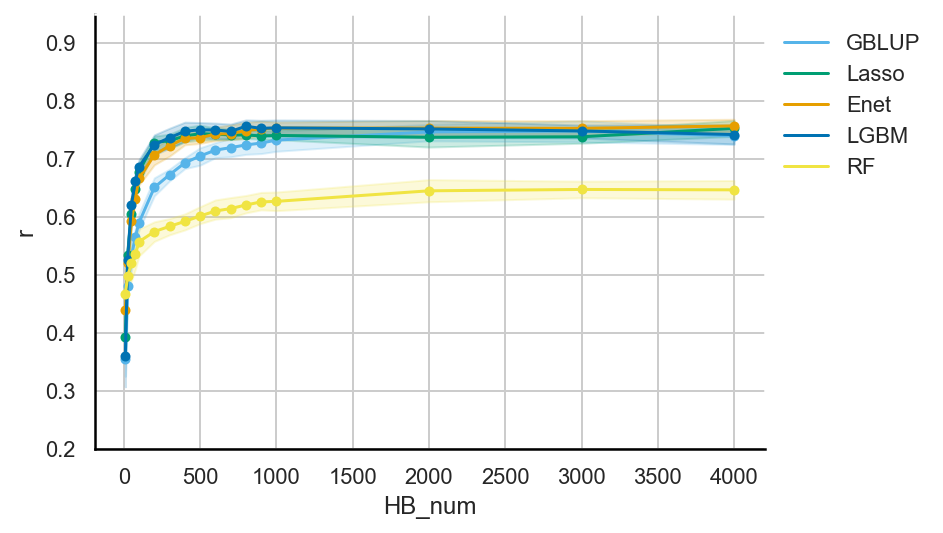

DTH_mean


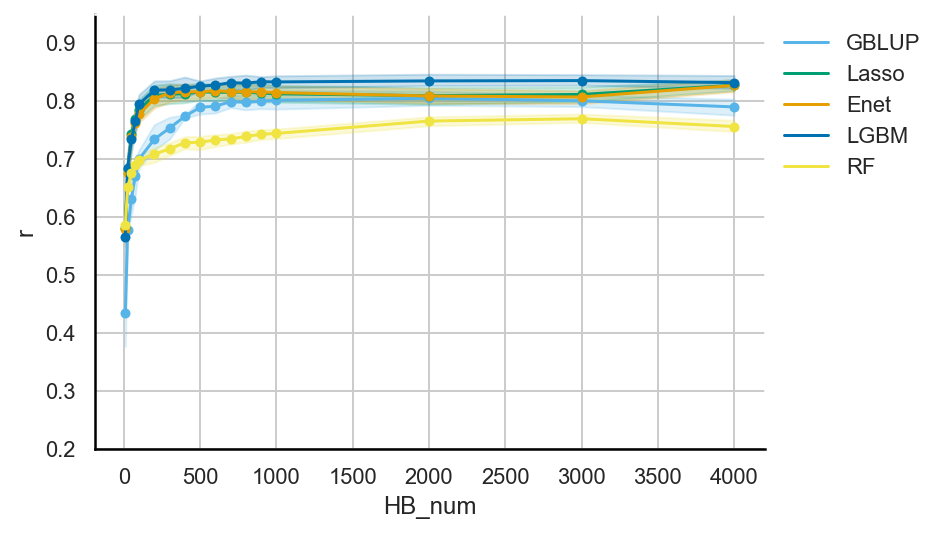

PN_mean


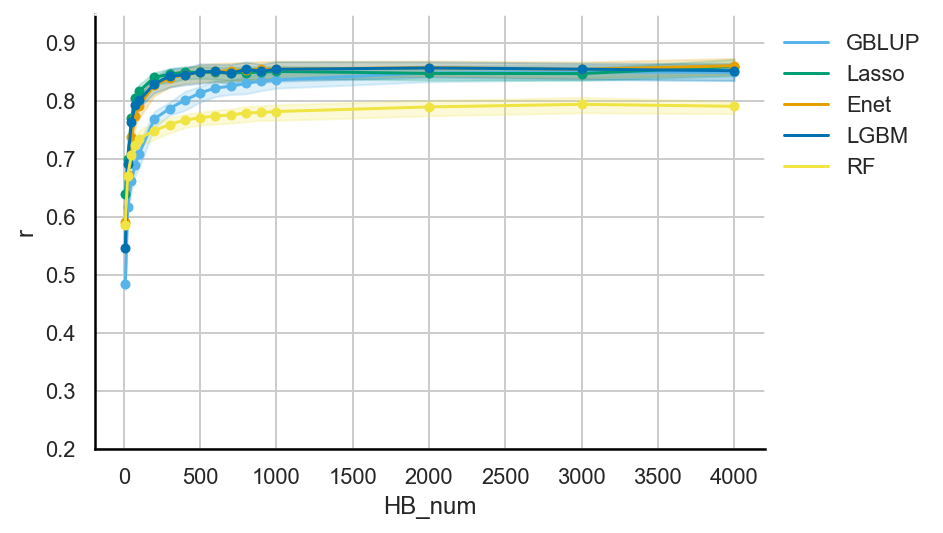

Area.size.AS..mm2.


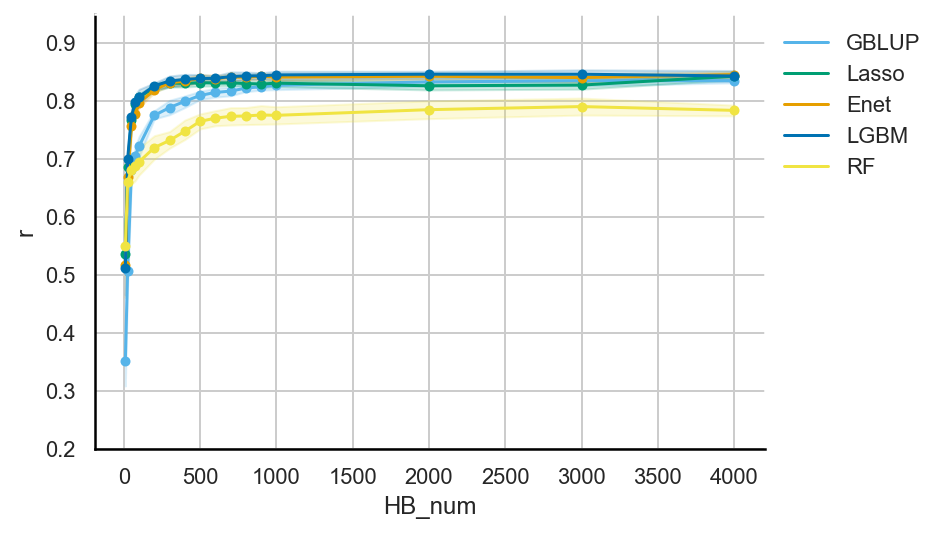

In [3]:
with open('../data/PART4_Small_number_HBs/Compare_models_by_all_RILs_selected_HBs_byDCV.pic.bin', 'rb') as p:
    summary = pickle.load(p)
summary = pd.DataFrame(summary)

for trait_name in trait_names:
    with open('../data/PART3_Model_comparison/Compare_models_DCV_by_all_RILs_HBs_{}.pic.bin'.format(trait_name), 'rb') as p:
        each_summary = pickle.load(p)
    each_summary = pd.DataFrame(each_summary)
    each_summary["HB_num"] = np.repeat(4000, each_summary.shape[0])
    each_summary = each_summary.iloc[:, [0,7,2,1,3,4,5,6]]
    each_summary.columns = range(8)
    each_summary = each_summary.loc[each_summary.iloc[:, 2].isin(models), :]
    summary = pd.concat([each_summary, summary])
summary = summary.reset_index(drop=True)
summary = summary.sort_values(2, key=lambda col: col.map(model_order))

sns.set(style='whitegrid', color_codes=True)
for trait_name in trait_names:
    print(trait_name)
    trait_summary = summary[summary.iloc[:, 0] == trait_name]
    trait_summary = trait_summary.iloc[:, [1,2,3,5]]
    trait_summary.columns = ["HB_num", "model", "CV", "r"]
    ax = sns.lineplot(data=trait_summary, x="HB_num", y="r", hue="model", marker="o", markersize=5, markeredgewidth=0, palette=palette)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color('black')
    for sp in ["right", "top"]:
        ax.spines[sp].set_color('white')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None, frameon=False)
    plt.ylim(0.2, 0.95)
    plt.show()

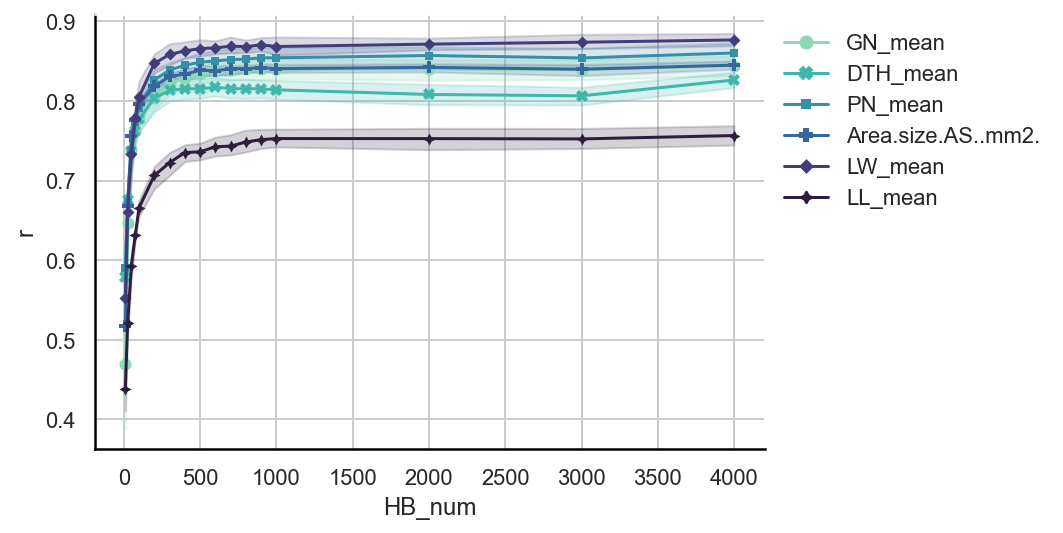

In [4]:
Enet_summary = summary[summary.iloc[:, 2] == "Enet"].iloc[:, [0,1,2,3,5]]
Enet_summary.columns = ["trait", "HB_num", "model", "CV", "r"]
palette = sns.color_palette("mako_r", 6)
ax = sns.lineplot(data=Enet_summary, x="HB_num", y="r", hue="trait", style="trait", palette=palette, markers=True, dashes=False, markeredgewidth=0)
for sp in ["left", "bottom"]:
    ax.spines[sp].set_color('black')
for sp in ["right", "top"]:
    ax.spines[sp].set_color('white')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title=None, frameon=False,)
plt.show()